In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
final_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Time series/Project/final_df.csv", index_col=0)

In [ ]:
brent = final_df[['Brent_price']]

In [ ]:
brent.head()

,Brent_price
2003-01-01,30.808696
2003-02-01,32.662500
2003-03-01,30.168095
2003-04-01,25.035000
2003-05-01,25.714545


In [ ]:
from prophet import Prophet

# Reset index and rename columns
df_brent = brent.reset_index()
df_brent.columns = ["ds", "y"]
df_brent["ds"] = pd.to_datetime(df_brent["ds"])
df_brent.head()

,ds,y
0,2003-01-01,30.808696
1,2003-02-01,32.662500
2,2003-03-01,30.168095
3,2003-04-01,25.035000
4,2003-05-01,25.714545


In [ ]:
!pip install sktime

In [ ]:
from sktime.forecasting.all import temporal_train_test_split

train, test = temporal_train_test_split(df_brent, test_size=24)

## Baseline Prophet model:

In [ ]:
from prophet import Prophet

# baseline Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# fit on training data
model.fit(train)

# make future dataframe for the test horizon
future = model.make_future_dataframe(periods=len(test), freq="MS")

# forecast
forecast = model.predict(future)

# keep only forecast period that matches test set
forecast_test = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(len(test))

forecast_test.head()

,ds,yhat,yhat_lower,yhat_upper
250,2023-11-01,63.792321,34.030386,89.271064
251,2023-12-01,61.313605,32.700095,87.803935
252,2024-01-01,60.952368,35.604435,89.026000
253,2024-02-01,62.425103,33.421916,89.095115
254,2024-03-01,64.663025,37.230788,90.172049


In [ ]:
# merge actual and predicted values
results = test.merge(forecast_test, on="ds", how="left")

results.head()

,ds,y,yhat,yhat_lower,yhat_upper
0,2023-11-01,82.186364,63.792321,34.030386,89.271064
1,2023-12-01,77.540952,61.313605,32.700095,87.803935
2,2024-01-01,79.110000,60.952368,35.604435,89.026000
3,2024-02-01,81.795714,62.425103,33.421916,89.095115
4,2024-03-01,84.961429,64.663025,37.230788,90.172049


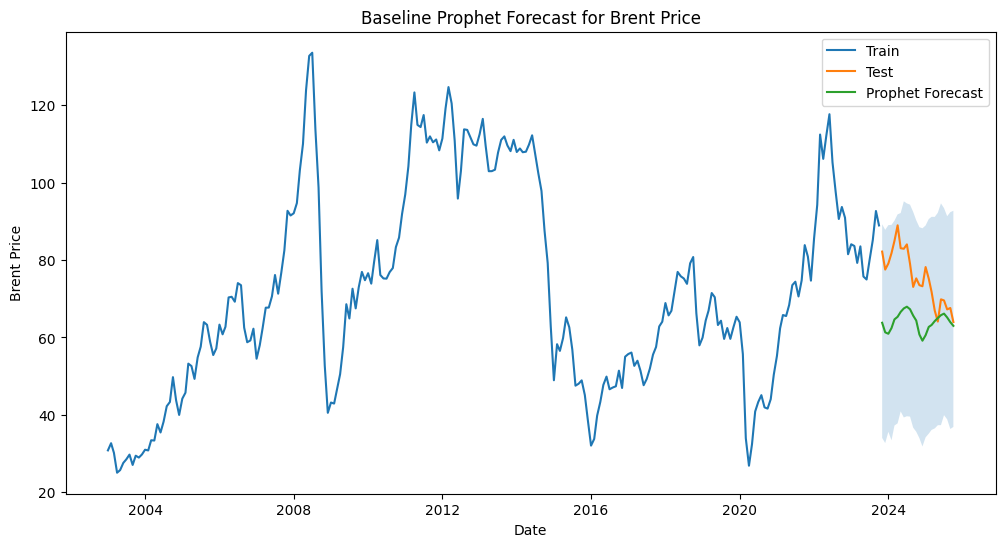

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(train["ds"], train["y"], label="Train")
plt.plot(test["ds"], test["y"], label="Test")
plt.plot(results["ds"], results["yhat"], label="Prophet Forecast")
plt.fill_between(
    results["ds"],
    results["yhat_lower"],
    results["yhat_upper"],
    alpha=0.2
)
plt.legend()
plt.title("Baseline Prophet Forecast for Brent Price")
plt.xlabel("Date")
plt.ylabel("Brent Price")
plt.show()

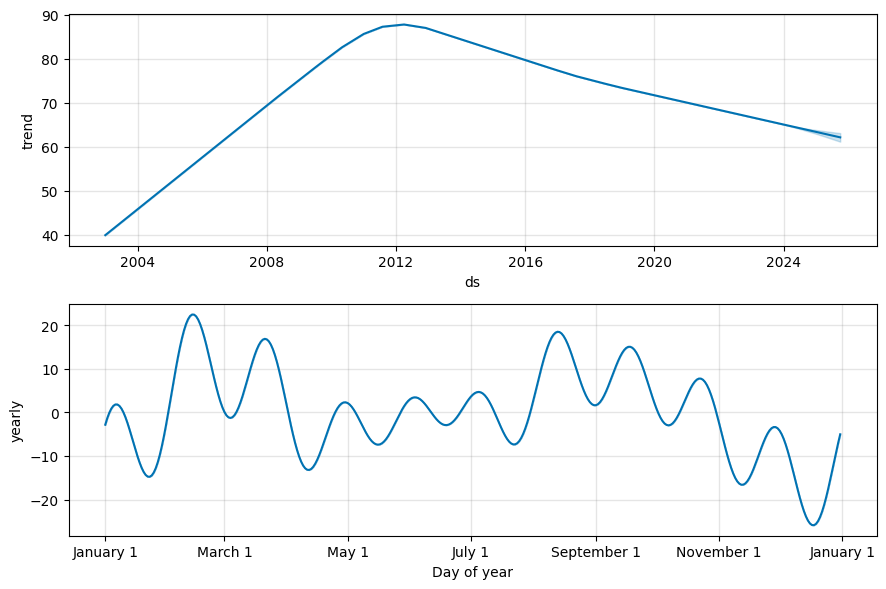

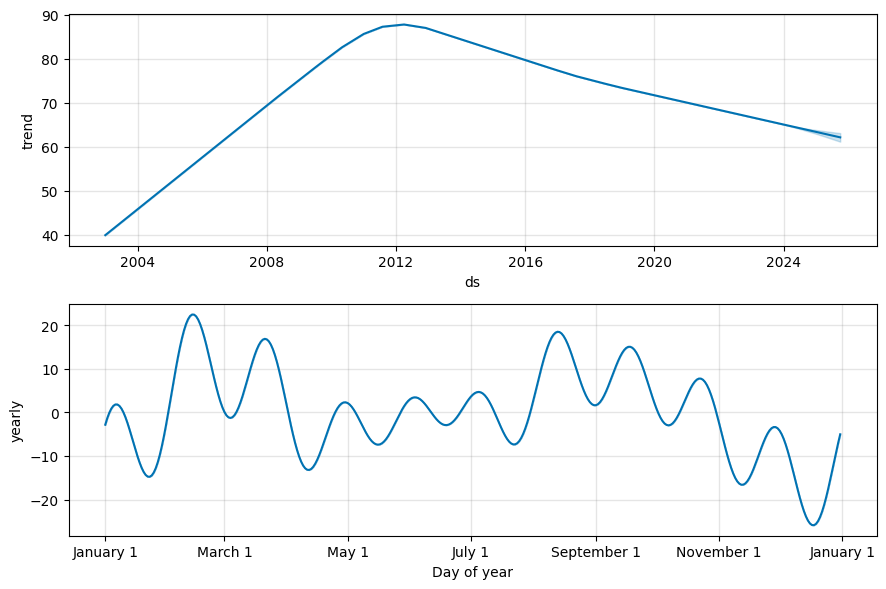

In [ ]:
model.plot_components(forecast)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = results["y"].values
y_pred_baseline = results["yhat"].values

# MAE
mae_baseline = mean_absolute_error(y_true, y_pred_baseline)

# MSE
mse_baseline = mean_squared_error(y_true, y_pred_baseline)

# MAPE
mape_baseline = np.mean(np.abs((y_true - y_pred_baseline) / y_true)) * 100

# sMAPE
smape_baseline = 100 * np.mean(
    2 * np.abs(y_pred_baseline - y_true) / (np.abs(y_true) + np.abs(y_pred_baseline))
)

# MASE
seasonal_lag = 12
naive_errors = train["y"].values[seasonal_lag:] - train["y"].values[:-seasonal_lag]
mae_naive = np.mean(np.abs(naive_errors))

mase_baseline = mae_baseline / mae_naive

print("MAE:", mae_baseline)
print("MSE:", mse_baseline)
print("MAPE:", mape_baseline)
print("sMAPE:", smape_baseline)
print("MASE:", mase_baseline)

MAE: 11.55793555889961
MSE: 179.62599153716175
MAPE: 14.636673375824039
sMAPE: 16.182336619453004
MASE: 0.5735096724272196


## Tuned Prophet Model:

In [ ]:
'''
# Parameter grid
cp_values = np.linspace(0.001, 0.5, 5)
sp_values = np.linspace(0.01, 10, 5)

results_list = []

# Loop over grid
for cp in cp_values:
    for sp in sp_values:

        model = Prophet(
            yearly_seasonality=True,
            changepoint_prior_scale=cp,
            seasonality_prior_scale=sp,
            growth="linear",
            weekly_seasonality=False,
            daily_seasonality=False
        )

        model.fit(train)

        future = model.make_future_dataframe(
            periods=len(test),
            freq="MS"
        )

        forecast = model.predict(future)

        forecast_test = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(len(test))

        results = test.merge(forecast_test, on="ds", how="left")

        y_true = results["y"].values
        y_pred = results["yhat"].values

        # Metrics
        # MAE
        mae = mean_absolute_error(y_true, y_pred)

        # MSE
        mse = mean_squared_error(y_true, y_pred)

        # MAPE
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

        # sMAPE
        smape = 100 * np.mean(
          2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
        )

        # MASE
        # scale using naive forecast from training data
        naive = train["y"].diff().dropna()
        scale = np.mean(np.abs(naive))

        mase = np.mean(np.abs(y_true - y_pred)) / scale

        results_list.append({
            "cp_scale": cp,
            "seasonality_scale": sp,
            "MAE": mae,
            "MSE": mse,
            "MAPE": mape,
            "sMAPE": smape,
            "MASE": mase
        })

# Results dataframe
tuning_results = pd.DataFrame(results_list)
'''

'\n# Parameter grid\ncp_values = np.linspace(0.001, 0.5, 5)\nsp_values = np.linspace(0.01, 10, 5)\n\nresults_list = []\n\n# Loop over grid\nfor cp in cp_values:\n    for sp in sp_values:\n\n        model = Prophet(\n            yearly_seasonality=True,\n            changepoint_prior_scale=cp,\n            seasonality_prior_scale=sp,\n            growth="linear",\n            weekly_seasonality=False,\n            daily_seasonality=False\n        )\n\n        model.fit(train)\n\n        future = model.make_future_dataframe(\n            periods=len(test),\n            freq="MS"\n        )\n\n        forecast = model.predict(future)\n\n        forecast_test = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(len(test))\n\n        results = test.merge(forecast_test, on="ds", how="left")\n\n        y_true = results["y"].values\n        y_pred = results["yhat"].values\n\n        # Metrics\n        # MAE\n        mae = mean_absolute_error(y_true, y_pred)\n\n        # MSE\n        mse

In [ ]:
# Best model by MAE
'''
best_model = tuning_results.sort_values("MAPE").reset_index(drop=True)

best_model.head()
'''

'\nbest_model = tuning_results.sort_values("MAPE").reset_index(drop=True)\n\nbest_model.head()\n'

In [ ]:
# Tuned Prophet model
model_tuned = Prophet(
    yearly_seasonality=True,
    changepoint_prior_scale=0.06,
    seasonality_prior_scale=10,
    weekly_seasonality=False,
    daily_seasonality=False
)

# fit on training data
model_tuned.fit(train)

# make future dataframe for the test horizon
future_tuned = model_tuned.make_future_dataframe(periods=len(test), freq="MS")

# forecast
forecast_tuned = model_tuned.predict(future_tuned)

# keep only forecast period that matches test set
forecast_test_tuned = forecast_tuned[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(len(test))

forecast_test_tuned.columns = ["ds", "yhat_tuned", "yhat_lower_tuned", "yhat_upper_tuned"]
forecast_test_tuned.head()

,ds,yhat_tuned,yhat_lower_tuned,yhat_upper_tuned
250,2023-11-01,74.345743,50.042495,98.671572
251,2023-12-01,71.615187,45.830652,94.749898
252,2024-01-01,70.824416,46.275991,94.823525
253,2024-02-01,72.273700,49.105540,97.345514
254,2024-03-01,75.349094,50.361336,99.255075


In [ ]:
# merge actual and predicted values
results = results.merge(forecast_test_tuned, on="ds", how="left")

results.head()

,ds,y,yhat,yhat_lower,yhat_upper,yhat_tuned,yhat_lower_tuned,yhat_upper_tuned
0,2023-11-01,82.186364,63.792321,34.030386,89.271064,74.345743,50.042495,98.671572
1,2023-12-01,77.540952,61.313605,32.700095,87.803935,71.615187,45.830652,94.749898
2,2024-01-01,79.110000,60.952368,35.604435,89.026000,70.824416,46.275991,94.823525
3,2024-02-01,81.795714,62.425103,33.421916,89.095115,72.273700,49.105540,97.345514
4,2024-03-01,84.961429,64.663025,37.230788,90.172049,75.349094,50.361336,99.255075


In [ ]:
y_true = results["y"].values
y_pred_tuned = results["yhat_tuned"].values

# MAE
mae_tuned = mean_absolute_error(y_true, y_pred_tuned)

# MSE
mse_tuned = mean_squared_error(y_true, y_pred_tuned)

# MAPE
mape_tuned = np.mean(np.abs((y_true - y_pred_tuned) / y_true)) * 100

# sMAPE
smape_tuned = 100 * np.mean(
    2 * np.abs(y_pred_tuned - y_true) / (np.abs(y_true) + np.abs(y_pred_tuned))
)

# MASE
seasonal_lag = 12
naive_errors = train["y"].values[seasonal_lag:] - train["y"].values[:-seasonal_lag]
mae_naive = np.mean(np.abs(naive_errors))
mase_tuned = mae_tuned / mae_naive

print("MAE:", mae_tuned)
print("MSE:", mse_tuned)
print("MAPE:", mape_tuned)
print("sMAPE:", smape_tuned)
print("MASE:", mase_tuned)

MAE: 7.423841272129013
MSE: 77.39499187953443
MAPE: 10.165138121769123
sMAPE: 9.817694184006426
MASE: 0.36837415768874027


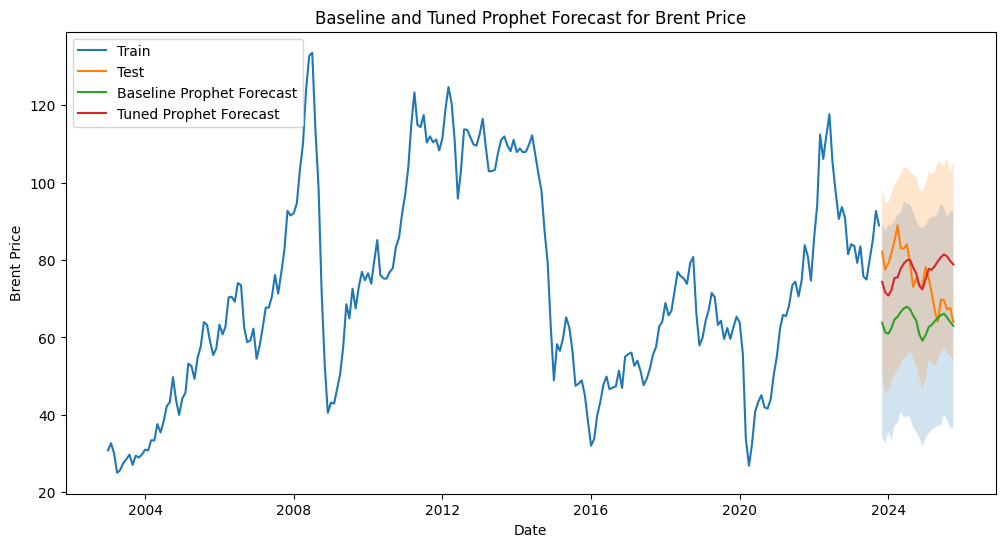

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(train["ds"], train["y"], label="Train")
plt.plot(test["ds"], test["y"], label="Test")
plt.plot(results["ds"], results["yhat"], label="Baseline Prophet Forecast")
plt.plot(results["ds"], results["yhat_tuned"], label="Tuned Prophet Forecast")
plt.fill_between(
    results["ds"],
    results["yhat_lower"],
    results["yhat_upper"],
    alpha=0.2
)
plt.fill_between(
    results["ds"],
    results["yhat_lower_tuned"],
    results["yhat_upper_tuned"],
    alpha=0.2
)
plt.legend()
plt.title("Baseline and Tuned Prophet Forecast for Brent Price")
plt.xlabel("Date")
plt.ylabel("Brent Price")
plt.show()

In [ ]:
results.head()

,ds,y,yhat,yhat_lower,yhat_upper,yhat_tuned,yhat_lower_tuned,yhat_upper_tuned
0,2023-11-01,82.186364,63.792321,34.030386,89.271064,74.345743,50.042495,98.671572
1,2023-12-01,77.540952,61.313605,32.700095,87.803935,71.615187,45.830652,94.749898
2,2024-01-01,79.110000,60.952368,35.604435,89.026000,70.824416,46.275991,94.823525
3,2024-02-01,81.795714,62.425103,33.421916,89.095115,72.273700,49.105540,97.345514
4,2024-03-01,84.961429,64.663025,37.230788,90.172049,75.349094,50.361336,99.255075


In [ ]:
results['residual'] = results['y'] - results['yhat_tuned']
resid_tuned = results[['ds', 'residual']].set_index('ds')
results = results.drop(columns='residual')

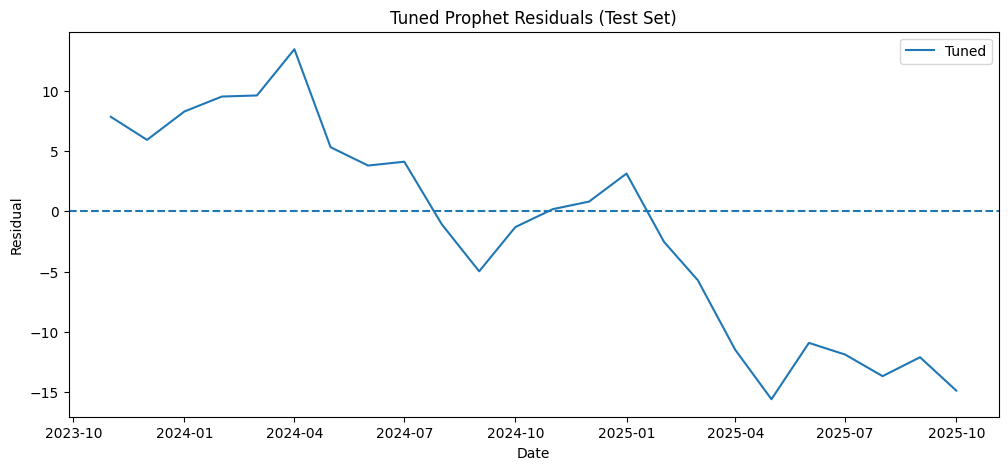

In [ ]:
# Residual Time Series Plot
plt.figure(figsize=(12,5))
plt.plot(resid_tuned, label="Tuned")
plt.axhline(0, linestyle="--")
plt.title("Tuned Prophet Residuals (Test Set)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

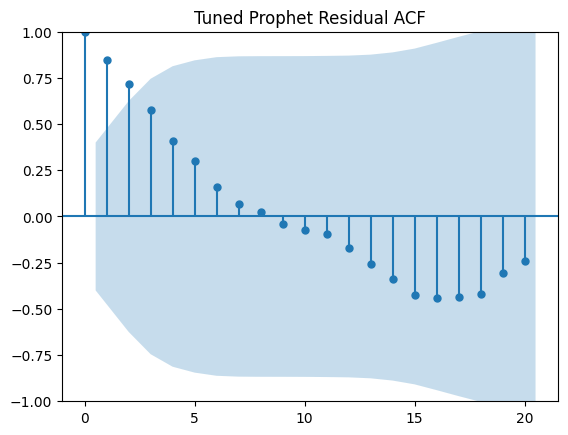

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Residual ACF
plot_acf(resid_tuned, lags=20)
plt.title("Tuned Prophet Residual ACF")
plt.show()

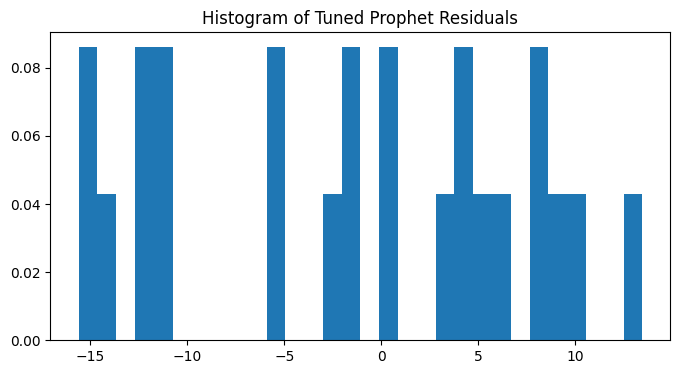

In [ ]:
# Histogram
plt.figure(figsize=(8,4))
plt.hist(resid_tuned, bins=30, density=True)
plt.title("Histogram of Tuned Prophet Residuals")
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box test (Tuned)
acorr_ljungbox(resid_tuned, lags=[1,5,10,12], return_df=True)

,lb_stat,lb_pvalue
1,19.467281,1.023377e-05
5,52.108528,5.125239e-10
10,53.464548,6.103722e-08
12,55.359910,1.559913e-07


## Tuned + Regressors Prophet Model:

In [ ]:
df_prophet = df_brent.copy()

df_prophet["world_crude_supply"] = final_df["world_crude_supply"].values
df_prophet["global_demand_proxy"] = final_df["global_demand_proxy"].values

In [ ]:
train, test = temporal_train_test_split(df_prophet, test_size=24)

In [ ]:
model_regressor = Prophet(
    yearly_seasonality=True,
    changepoint_prior_scale=0.06,
    seasonality_prior_scale=5,
    weekly_seasonality=False,
    daily_seasonality=False
)

model_regressor.add_regressor("world_crude_supply")
model_regressor.add_regressor("global_demand_proxy")

model_regressor.fit(train)

future_regressor = model_regressor.make_future_dataframe(
    periods=len(test),
    freq="MS"
)

future_regressor["world_crude_supply"] = df_prophet["world_crude_supply"].values
future_regressor["global_demand_proxy"] = df_prophet["global_demand_proxy"].values

forecast_regressor = model_regressor.predict(future_regressor)

forecast_test_regressor = forecast_regressor[["ds","yhat","yhat_lower","yhat_upper"]].tail(len(test))

forecast_test_regressor.columns = ["ds", "yhat_regressor", "yhat_lower_regressor", "yhat_upper_regressor"]
forecast_test_regressor.head()

,ds,yhat_regressor,yhat_lower_regressor,yhat_upper_regressor
250,2023-11-01,78.072301,57.329380,99.773459
251,2023-12-01,80.594617,61.234460,103.403563
252,2024-01-01,76.734301,55.684360,98.172507
253,2024-02-01,85.041527,64.661023,106.299585
254,2024-03-01,85.988590,65.493541,106.560631


In [ ]:
# merge actual and predicted values
results = results.merge(forecast_test_regressor, on="ds", how="left")

results.head()

,ds,y,yhat,yhat_lower,yhat_upper,yhat_tuned,yhat_lower_tuned,yhat_upper_tuned,yhat_regressor,yhat_lower_regressor,yhat_upper_regressor
0,2023-11-01,82.186364,63.792321,34.030386,89.271064,74.345743,50.042495,98.671572,78.072301,57.329380,99.773459
1,2023-12-01,77.540952,61.313605,32.700095,87.803935,71.615187,45.830652,94.749898,80.594617,61.234460,103.403563
2,2024-01-01,79.110000,60.952368,35.604435,89.026000,70.824416,46.275991,94.823525,76.734301,55.684360,98.172507
3,2024-02-01,81.795714,62.425103,33.421916,89.095115,72.273700,49.105540,97.345514,85.041527,64.661023,106.299585
4,2024-03-01,84.961429,64.663025,37.230788,90.172049,75.349094,50.361336,99.255075,85.988590,65.493541,106.560631


In [ ]:
y_true = results["y"].values
y_pred_regressor = results["yhat_regressor"].values

# MAE
mae_regressor = mean_absolute_error(y_true, y_pred_regressor)

# MSE
mse_regressor = mean_squared_error(y_true, y_pred_regressor)

# MAPE
mape_regressor = np.mean(np.abs((y_true - y_pred_regressor) / y_true)) * 100

# sMAPE
smape_regressor = 100 * np.mean(
    2 * np.abs(y_pred_regressor - y_true) / (np.abs(y_true) + np.abs(y_pred_regressor))
)

# MASE
seasonal_lag = 12
naive_errors = train["y"].values[seasonal_lag:] - train["y"].values[:-seasonal_lag]
mae_naive = np.mean(np.abs(naive_errors))
mase_regressor = mae_regressor / mae_naive

print("MAE:", mae_regressor)
print("MSE:", mse_regressor)
print("MAPE:", mape_regressor)
print("sMAPE:", smape_regressor)
print("MASE:", mase_regressor)

MAE: 8.498305385379098
MSE: 137.1095519444517
MAPE: 12.162530081526358
sMAPE: 10.933951814451941
MASE: 0.42168952343763244


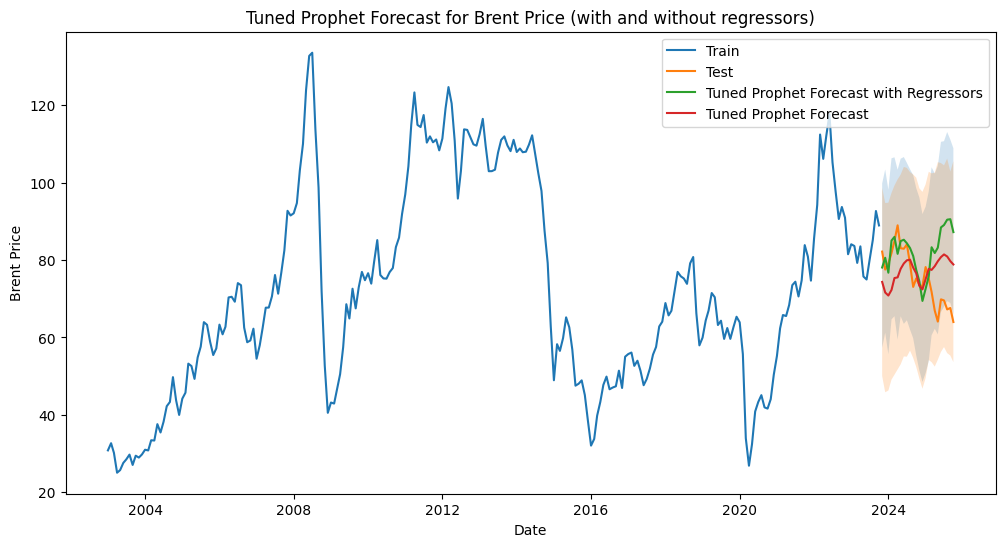

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(train["ds"], train["y"], label="Train")
plt.plot(test["ds"], test["y"], label="Test")
plt.plot(results["ds"], results["yhat_regressor"], label="Tuned Prophet Forecast with Regressors")
plt.plot(results["ds"], results["yhat_tuned"], label="Tuned Prophet Forecast")
plt.fill_between(
    results["ds"],
    results["yhat_lower_regressor"],
    results["yhat_upper_regressor"],
    alpha=0.2
)
plt.fill_between(
    results["ds"],
    results["yhat_lower_tuned"],
    results["yhat_upper_tuned"],
    alpha=0.2
)
plt.legend()
plt.title("Tuned Prophet Forecast for Brent Price (with and without regressors)")
plt.xlabel("Date")
plt.ylabel("Brent Price")
plt.show()

In [ ]:
results['residual'] = results['y'] - results['yhat_regressor']
resid_regressor = results[['ds', 'residual']].set_index('ds')
results = results.drop(columns='residual')

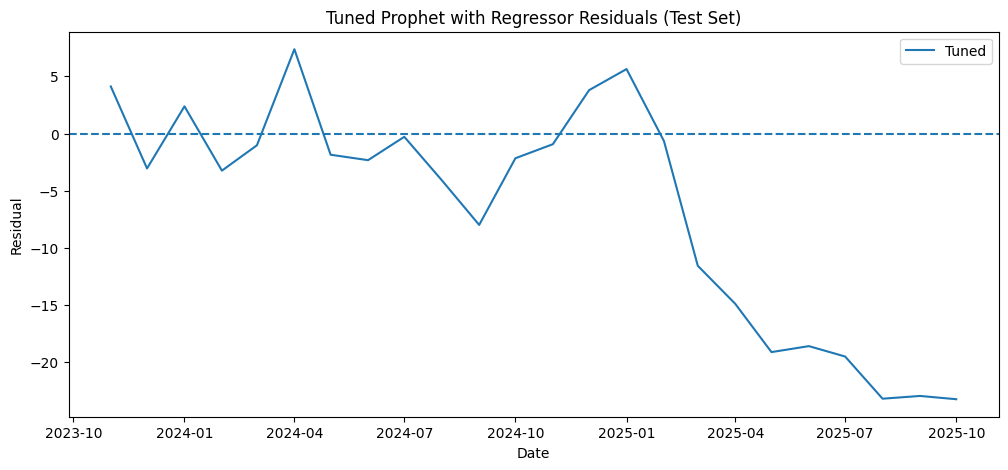

In [ ]:
# Residual Time Series Plot
plt.figure(figsize=(12,5))
plt.plot(resid_regressor, label="Tuned")
plt.axhline(0, linestyle="--")
plt.title("Tuned Prophet with Regressor Residuals (Test Set)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

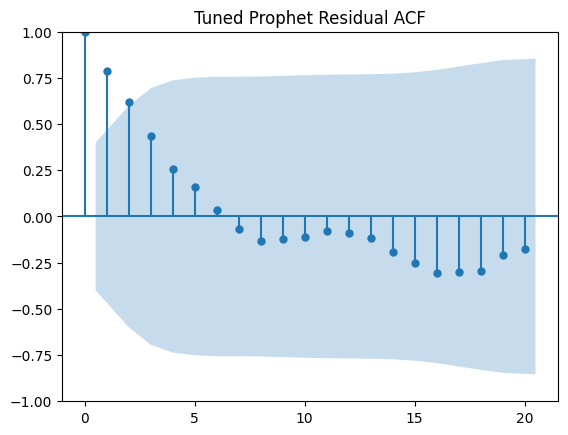

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Residual ACF
plot_acf(resid_regressor, lags=20)
plt.title("Tuned Prophet Residual ACF")
plt.show()

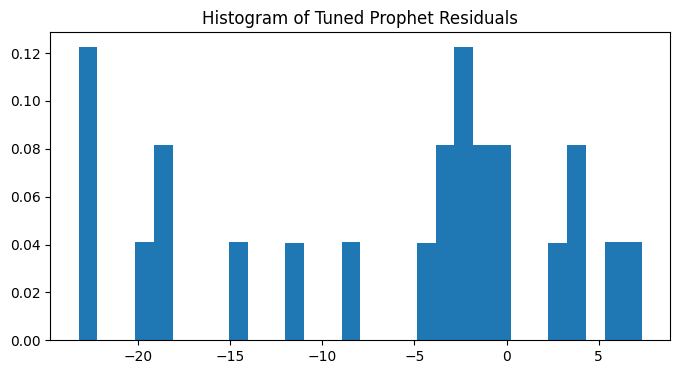

In [ ]:
# Histogram
plt.figure(figsize=(8,4))
plt.hist(resid_regressor, bins=30, density=True)
plt.title("Histogram of Tuned Prophet Residuals")
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box test (Tuned)
acorr_ljungbox(resid_regressor, lags=[1,5,10,12], return_df=True)

,lb_stat,lb_pvalue
1,16.797956,4.157806e-05
5,36.306965,8.245456e-07
10,38.362054,3.282000e-05
12,39.077388,1.021883e-04


Over a one year forecast horizon, prophet with regressors does really well. However, beyond 1yr the the forecast deviates heavily from the test actual values.

If we look at forecast errors for only 1 yr after the train set, we see errors drop drastically.

In [ ]:
y_true = results["y"].values
y_pred_regressor = results["yhat_regressor"].values


# MAE
mae_regressor = mean_absolute_error(y_true[:12], y_pred_regressor[:12])

# MSE
mse_regressor = mean_squared_error(y_true[:12], y_pred_regressor[:12])

# MAPE
mape_regressor = np.mean(np.abs((y_true[:12] - y_pred_regressor[:12]) / y_true[:12])) * 100

# sMAPE
smape_regressor = 100 * np.mean(
    2 * np.abs(y_pred_regressor[:12] - y_true[:12]) / (np.abs(y_true[:12]) + np.abs(y_pred_regressor[:12]))
)

# MASE
seasonal_lag = 12
naive_errors = train["y"].values[seasonal_lag:] - train["y"].values[:-seasonal_lag]
mae_naive = np.mean(np.abs(naive_errors))
mase_regressor = mae_regressor / mae_naive

print("MAE:", mae_regressor)
print("MSE:", mse_regressor)
print("MAPE:", mape_regressor)
print("sMAPE:", smape_regressor)
print("MASE:", mase_regressor)

MAE: 3.3246423405326113
MSE: 15.998160469544379
MAPE: 4.147601105928842
sMAPE: 4.11174650998783
MASE: 0.1649701652981057


In [ ]:
#results.to_csv('/content/drive/MyDrive/Colab Notebooks/Time series/Project/prophet_forecast.csv')